# PSet 1 — Problem 4 (Python)

Two-period labor supply with borrowing constraint.

In [11]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

here = Path.cwd()
repo_root = None
for p in [here] + list(here.parents):
    cand = p / 'Heterogeneity In Macroeconomics - Github'
    if cand.exists():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError('Could not locate hetmacro repo root')
sys.path.insert(0, str(repo_root))

from hetmacro import optimize as ho

In [12]:
# Parameters
p = {
    'beta': 0.90,
    'sigma': 1.5,
    'gamma': 2.0,
    'r': 0.04,
    'W': 1.0,
    'tau': 0.25,
    'T': 0.15,
}

## Helper functions

Given consumption $c$, we back out hours from the labor FOC and compute implied savings $a'$.

In [13]:
def h_from_c(c, e, p):
    c = np.asarray(c)
    K = (1.0 - p['tau']) * p['W'] * e
    return (K * c ** (-p['sigma'])) ** (1.0 / p['gamma'])

def savings(c, a, e, p):
    h = h_from_c(c, e, p)
    return p['T'] + (1.0 - p['tau']) * p['W'] * e * h + (1.0 + p['r']) * a - c

def valfunc2(a, e, p):
    # Solve for c2 such that a3 = savings(c2,a,e)=0
    # Use hetmacro bisection for each element (loop).
    a = np.asarray(a)
    c2 = np.empty_like(a, dtype=float)
    h2 = np.empty_like(a, dtype=float)
    a3 = np.empty_like(a, dtype=float)
    v2 = np.empty_like(a, dtype=float)
    for idx, aval in np.ndenumerate(a):
        # bracket: consumption in (0, cash-on-hand + labor income upper bound)
        # crude upper bound
        ub = p['T'] + (1.0 + p['r']) * aval + (1.0 - p['tau']) * p['W'] * e * 10.0
        lb = 1e-10
        root = ho.bisect(lambda c: savings(c, aval, e, p), lb, ub, tol=1e-10)
        c2[idx] = root
        h2[idx] = h_from_c(root, e, p)
        a3[idx] = savings(root, aval, e, p)
        v2[idx] = (root ** (1.0 - p['sigma'])) / (1.0 - p['sigma']) - (h2[idx] ** (1.0 + p['gamma'])) / (1.0 + p['gamma'])
    return v2, c2, h2, a3

## 1) Test period-2 solver

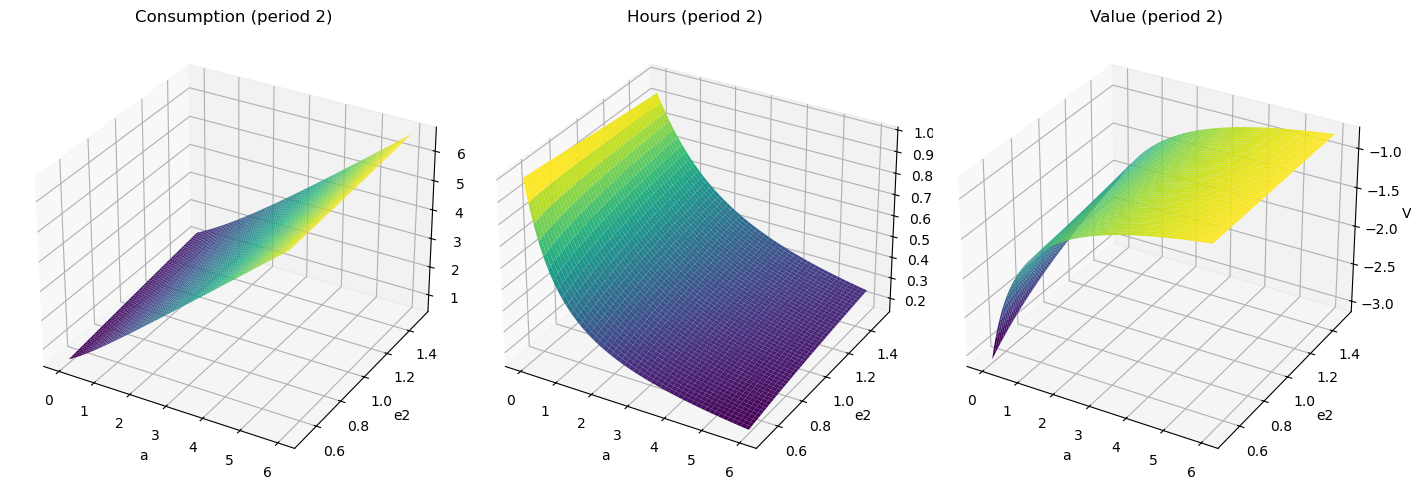

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# Grid: a (period-2 assets), e2 (period-2 productivity)
aa = np.linspace(0.0, 6.0, 200)
e2_grid = np.linspace(0.5, 1.5, 1000)

# Build 2D arrays over (a, e2): rows = e2, cols = a
c2_2d = np.zeros((len(e2_grid), len(aa)))
h2_2d = np.zeros((len(e2_grid), len(aa)))
v2_2d = np.zeros((len(e2_grid), len(aa)))
for j, e2 in enumerate(e2_grid):
    v2, c2, h2, _ = valfunc2(aa, e2, p)
    c2_2d[j, :] = c2
    h2_2d[j, :] = h2
    v2_2d[j, :] = v2

# 2D meshes for surface plots: X = a, Y = e2, Z = value
A_mesh, E2_mesh = np.meshgrid(aa, e2_grid)

# 3D surface plots
fig = plt.figure(figsize=(14, 5))

ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.plot_surface(A_mesh, E2_mesh, c2_2d, cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('a')
ax.set_ylabel('e2')
ax.set_zlabel('c2')
ax.set_title('Consumption (period 2)')

ax = fig.add_subplot(1, 3, 2, projection='3d')
ax.plot_surface(A_mesh, E2_mesh, h2_2d, cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('a')
ax.set_ylabel('e2')
ax.set_zlabel('h2')
ax.set_title('Hours (period 2)')

ax = fig.add_subplot(1, 3, 3, projection='3d')
ax.plot_surface(A_mesh, E2_mesh, v2_2d, cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('a')
ax.set_ylabel('e2')
ax.set_zlabel('V2')
ax.set_title('Value (period 2)')

plt.tight_layout()
plt.show()

## 2) Solve period-1 for each $e_2$

We find a feasible upper bound $\bar c_1$ such that $a_2(\bar c_1)=0$, then maximize period-1 value over $c_1\in(0,\bar c_1]$.

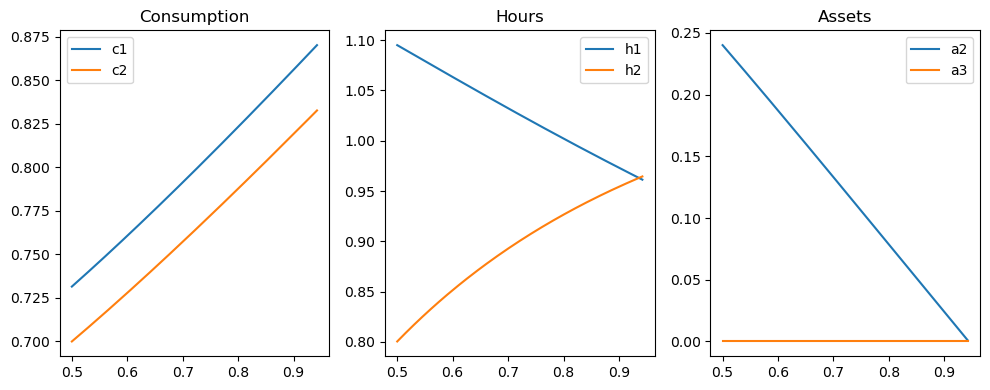

In [18]:
e_grid = np.linspace(0.5, 1.5, 200)  # smaller default for speed; can raise to 1000

def valfunc1(c1, e2, p):
    # given c1, recover h1, a2, then add beta*V2(a2,e2)
    e1 = 1.0
    h1 = h_from_c(c1, e1, p)
    a2 = p['T'] + (1.0 - p['tau']) * p['W'] * e1 * h1 - c1
    if a2 < 0:
        return -1e12
    v2, *_ = valfunc2(np.array([a2]), e2, p)
    u1 = (c1 ** (1.0 - p['sigma'])) / (1.0 - p['sigma']) - (h1 ** (1.0 + p['gamma'])) / (1.0 + p['gamma'])
    return u1 + p['beta'] * v2[0]

c1 = np.empty_like(e_grid)
h1 = np.empty_like(e_grid)
a2 = np.empty_like(e_grid)
c2 = np.empty_like(e_grid)
h2 = np.empty_like(e_grid)
a3 = np.empty_like(e_grid)

for i, e2 in enumerate(e_grid):
    # (A) Max feasible c1 such that a2=0 when e1=1 and a1=0 (hetmacro bisection)
    cmax = ho.bisect(lambda c: savings(c, 0.0, 1.0, p), 1e-10, 100.0, tol=1e-10)
    # (B) Maximize period-1 value over c1 in (0, cmax] using hetmacro golden search
    c1[i] = ho.golden_search(lambda c: -valfunc1(c, e2, p), 1e-8, cmax, tol=1e-8)
    h1[i] = h_from_c(c1[i], 1.0, p)
    a2[i] = savings(c1[i], 0.0, 1.0, p)
    v2, c2_i, h2_i, a3_i = valfunc2(np.array([a2[i]]), e2, p)
    c2[i], h2[i], a3[i] = c2_i[0], h2_i[0], a3_i[0]

euler_err = c1 ** (-p['sigma']) - p['beta'] * (1.0 + p['r']) * c2 ** (-p['sigma'])

# Mask plots to interior points where a2 > 0 (non-binding)
mask = a2 <= 1e-8
c1_m = np.ma.masked_where(mask, c1)
c2_m = np.ma.masked_where(mask, c2)
h1_m = np.ma.masked_where(mask, h1)
h2_m = np.ma.masked_where(mask, h2)
a2_m = np.ma.masked_where(mask, a2)
a3_m = np.ma.masked_where(mask, a3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.plot(e_grid, c1_m, label='c1')
plt.plot(e_grid, c2_m, label='c2')
plt.legend()
plt.title('Consumption')

plt.subplot(1, 3, 2)
plt.plot(e_grid, h1_m, label='h1')
plt.plot(e_grid, h2_m, label='h2')
plt.legend()
plt.title('Hours')

plt.subplot(1, 3, 3)
plt.plot(e_grid, a2_m, label='a2')
plt.plot(e_grid, a3_m, label='a3')
plt.legend()
plt.title('Assets')

plt.tight_layout()
plt.show()

## Pause / check
- $a_3$ should be numerically close to 0.
- Euler error should be small away from constraints.